# Projeto de Data Science — Jogadores de Futebol
## Notebook 03 — Modelagem

---

Este notebook aplica três técnicas vistas na disciplina, em duas frentes:

**Parte A — Aprendizado não-supervisionado (K-Means):** descobrir se os atributos
técnicos agrupam os jogadores em perfis que correspondem às posições reais em
campo (responde à hipótese **H4**).

**Parte B — Aprendizado supervisionado (Regressão):** prever o valor de mercado e
comparar dois algoritmos — **Regressão Linear** e **K-Nearest Neighbors (KNN)** —
para descobrir qual erra menos.

Ao final, salvamos os artefatos (modelo treinado, clusters) que alimentarão o
dashboard interativo.

## 1. Configuração e dados

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, r2_score,
                             root_mean_squared_error, silhouette_score)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

SETOR_CORES = {"Defensor": "#2471a3", "Meio-campo": "#16a085", "Atacante": "#c0392b"}
SETOR_ORDEM = ["Defensor", "Meio-campo", "Atacante"]

df = pd.read_csv("../data/players_clean.csv")
print(f"Dataset: {df.shape[0]:,} jogadores x {df.shape[1]} colunas")

Dataset: 17,041 jogadores x 61 colunas


# Parte A — K-Means: perfis de jogadores

## 2. Preparação dos dados para clusterização

Usaremos os **29 atributos técnicos detalhados**. Como o K-Means se baseia em
**distância euclidiana**, é indispensável **padronizar** as variáveis (média 0,
desvio 1) — caso contrário, atributos com maior amplitude dominariam o cálculo.

In [2]:
attrs_det = [c for c in df.columns if c.startswith(
    ("attacking_", "skill_", "movement_", "power_", "mentality_", "defending_"))
    and c != "skill_moves"]
print(f"{len(attrs_det)} atributos usados na clusterização.")

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[attrs_det])

29 atributos usados na clusterização.


## 3. Escolha do número de clusters (k)

Combinamos dois critérios: o **método do cotovelo** (inércia, que mede a
compactação dos grupos) e o **coeficiente de silhueta** (que mede o quão bem
separados eles estão).

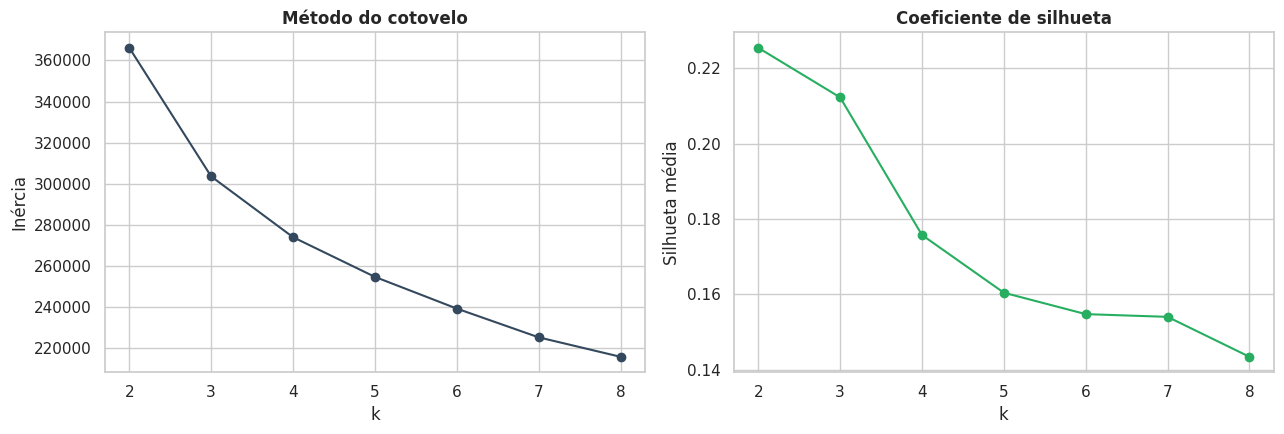

k=2: silhueta=0.225
k=3: silhueta=0.212
k=4: silhueta=0.176
k=5: silhueta=0.160
k=6: silhueta=0.155
k=7: silhueta=0.154
k=8: silhueta=0.143


In [3]:
ks = range(2, 9)
inercias, silhuetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    rotulos = km.fit_predict(X_cluster)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_cluster, rotulos))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(ks), inercias, marker="o", color="#34495e")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inércia")
axes[0].set_title("Método do cotovelo")

axes[1].plot(list(ks), silhuetas, marker="o", color="#27ae60")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhueta média")
axes[1].set_title("Coeficiente de silhueta")
plt.tight_layout(); plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta={s:.3f}")

A curva da inércia mostra um "cotovelo" na região de **k entre 2 e 4**, e a
silhueta é alta nessa mesma faixa. Como o objetivo é **confrontar os grupos com
os três setores de campo** (Defensor, Meio-campo, Atacante), adotamos **k = 3** —
uma escolha que é, ao mesmo tempo, estatisticamente razoável e diretamente
interpretável.

## 4. Ajuste do K-Means e visualização

Aplicamos o K-Means com k=3 e projetamos os jogadores em 2D via PCA para
visualizar os grupos. Comparamos lado a lado os **clusters encontrados** com os
**setores reais**.

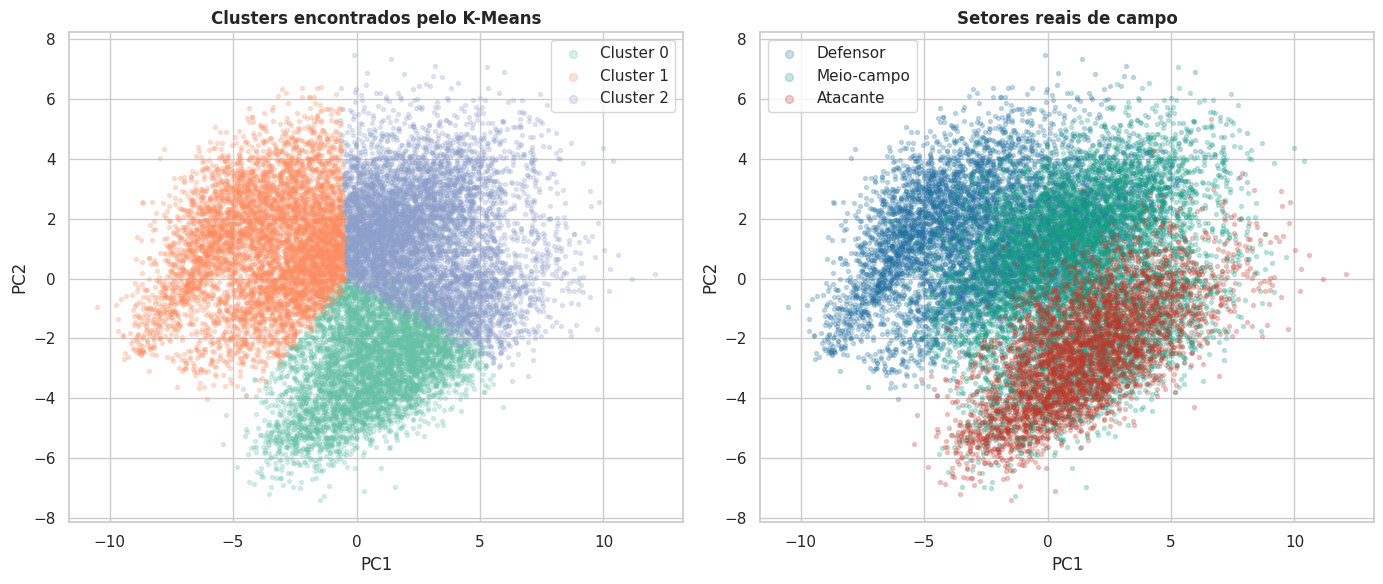

In [4]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster)

# Projeção PCA (2 componentes) para visualização
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster)
df["PC1"], df["PC2"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Esquerda: clusters do K-Means
paleta_cluster = sns.color_palette("Set2", K)
for c in range(K):
    m = df["cluster"] == c
    axes[0].scatter(df.loc[m, "PC1"], df.loc[m, "PC2"], s=8, alpha=0.25,
                    color=paleta_cluster[c], label=f"Cluster {c}")
axes[0].set_title("Clusters encontrados pelo K-Means")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(markerscale=2)

# Direita: setores reais
for setor in SETOR_ORDEM:
    m = df["field_sector"] == setor
    axes[1].scatter(df.loc[m, "PC1"], df.loc[m, "PC2"], s=8, alpha=0.25,
                    color=SETOR_CORES[setor], label=setor)
axes[1].set_title("Setores reais de campo")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend(markerscale=2)

plt.tight_layout(); plt.show()

## 5. Os clusters correspondem às posições?

Cruzamos os clusters com os setores reais. A heatmap mostra a composição de cada
cluster, e calculamos uma **taxa de concordância**: atribuindo a cada cluster o
setor majoritário, qual a fração de jogadores corretamente "classificados" por
esse processo **não-supervisionado**?

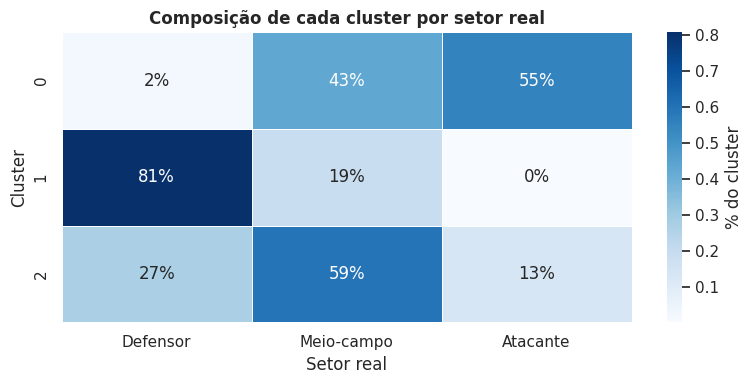

Setor majoritário de cada cluster:
cluster
0      Atacante
1      Defensor
2    Meio-campo

Taxa de concordância clusters x setores: 65.2%


In [5]:
tabela_cruz = pd.crosstab(df["cluster"], df["field_sector"])[SETOR_ORDEM]
composicao = tabela_cruz.div(tabela_cruz.sum(axis=1), axis=0)  # normaliza por cluster

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(composicao, annot=True, fmt=".0%", cmap="Blues", linewidths=0.5, ax=ax,
            cbar_kws={"label": "% do cluster"})
ax.set_title("Composição de cada cluster por setor real")
ax.set_xlabel("Setor real"); ax.set_ylabel("Cluster")
plt.tight_layout(); plt.show()

# Taxa de concordância (voto majoritário)
cluster_para_setor = tabela_cruz.idxmax(axis=1)
previsto = df["cluster"].map(cluster_para_setor)
concordancia = (previsto == df["field_sector"]).mean()
print("Setor majoritário de cada cluster:")
print(cluster_para_setor.to_string())
print(f"\nTaxa de concordância clusters x setores: {concordancia:.1%}")

A correspondência é **moderada a boa (~65%)** — bem acima da linha de base de um
palpite aleatório entre três grupos (~33%). Ou seja, os grupos formados **apenas a
partir dos atributos técnicos**, sem qualquer informação sobre a posição,
recuperam grande parte dos setores de campo, o que **dá suporte à H4**. A parcela
que não bate (~35%) é esperada e reflete posições genuinamente **híbridas** —
laterais e volantes, por exemplo, misturam características defensivas e de
meio-campo e por isso transitam entre os clusters.

## 6. Caracterização dos clusters (perfis)

Para dar identidade a cada grupo, observamos a média padronizada dos 6 atributos
agregados por cluster.

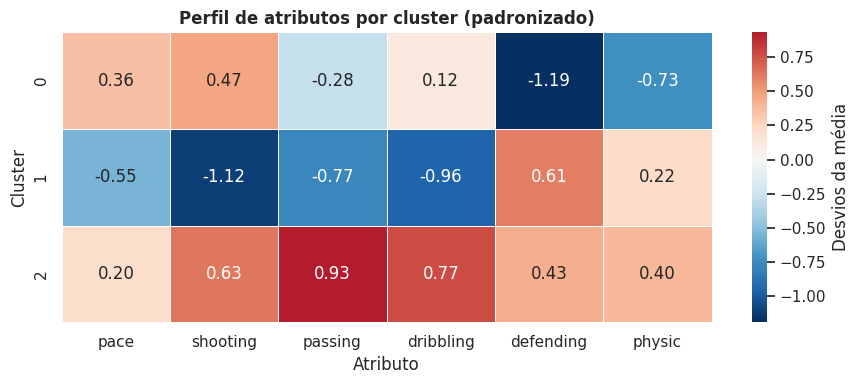

            n  overall_medio  valor_mediano_Meur setor_majoritario
cluster                                                           
0        5134          62.86                0.78          Atacante
1        5675          63.22                0.70          Defensor
2        6232          70.93                2.10        Meio-campo


In [6]:
attrs_agg = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
z_agg = (df[attrs_agg] - df[attrs_agg].mean()) / df[attrs_agg].std()
perfil_cluster = z_agg.groupby(df["cluster"]).mean()

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(perfil_cluster, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Desvios da média"})
ax.set_title("Perfil de atributos por cluster (padronizado)")
ax.set_xlabel("Atributo"); ax.set_ylabel("Cluster")
plt.tight_layout(); plt.show()

# Resumo numérico
resumo = df.groupby("cluster").agg(
    n=("sofifa_id", "size"),
    overall_medio=("overall", "mean"),
    valor_mediano_Meur=("value_eur", lambda x: x.median() / 1e6),
    setor_majoritario=("field_sector", lambda x: x.mode()[0]),
).round(2)
print(resumo)

Cada cluster tem um perfil nítido: um grupo se destaca em `defending`/`physic`
(perfil **defensivo**), outro em `passing`/`dribbling` (perfil **meio-campo/criação**)
e outro em `shooting`/`pace` (perfil **ofensivo**) — exatamente os três arquétipos
posicionais do futebol.

# Parte B — Regressão: previsão do valor de mercado

## 7. Definição de features e alvo

**Alvo:** `value_log` (o log do valor, como justificado na EDA).

**Features:** perfil físico, qualidade (overall, potential), reputação e os 35
atributos técnicos, mais o setor de campo (categórica). **Excluímos
deliberadamente `wage_eur`/`wage_log`** (near-leakage) e as colunas de
identificação.

In [7]:
alvo = "value_log"

features_num = [
    "age", "height_cm", "weight_kg", "bmi", "overall", "potential",
    "potential_gap", "weak_foot", "skill_moves", "international_reputation",
    "league_level"] + attrs_agg + attrs_det
features_cat = ["field_sector"]

X = df[features_num + features_cat].copy()
y = df[alvo].copy()
print(f"{len(features_num)} features numéricas + {len(features_cat)} categórica")
print(f"X: {X.shape}  |  y: {y.shape}")

46 features numéricas + 1 categórica
X: (17041, 47)  |  y: (17041,)


## 8. Divisão treino/teste e pré-processamento

Separamos 80% para treino e 20% para teste. O pré-processamento (padronização das
numéricas + *one-hot* da categórica) é encapsulado em um `ColumnTransformer` e
**ajustado apenas no treino**, evitando vazamento de informação do teste.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), features_cat),
])

Treino: 13,632 | Teste: 3,409


## 9. Modelo 1 — Regressão Linear

In [9]:
modelo_linear = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression()),
])
modelo_linear.fit(X_train, y_train)
pred_lin = modelo_linear.predict(X_test)

rmse_lin = root_mean_squared_error(y_test, pred_lin)
mae_lin = mean_absolute_error(y_test, pred_lin)
r2_lin = r2_score(y_test, pred_lin)
print(f"[Regressão Linear]  RMSE(log)={rmse_lin:.3f}  MAE(log)={mae_lin:.3f}  R²={r2_lin:.3f}")

[Regressão Linear]  RMSE(log)=0.197  MAE(log)=0.144  R²=0.973


## 10. Modelo 2 — KNN (com escolha de k por validação cruzada)

Para o KNN, o hiperparâmetro mais importante é o número de vizinhos *k*.
Usamos **validação cruzada (5 folds)** no conjunto de treino para escolher o
melhor valor, testando vários candidatos.

In [10]:
modelo_knn = Pipeline([
    ("prep", preprocess),
    ("reg", KNeighborsRegressor()),
])
grade = {"reg__n_neighbors": [3, 5, 7, 9, 11, 15, 21]}
busca = GridSearchCV(modelo_knn, grade, cv=5,
                     scoring="neg_root_mean_squared_error", n_jobs=-1)
busca.fit(X_train, y_train)

melhor_k = busca.best_params_["reg__n_neighbors"]
print(f"Melhor k encontrado: {melhor_k}")

pred_knn = busca.predict(X_test)
rmse_knn = root_mean_squared_error(y_test, pred_knn)
mae_knn = mean_absolute_error(y_test, pred_knn)
r2_knn = r2_score(y_test, pred_knn)
print(f"[KNN k={melhor_k}]  RMSE(log)={rmse_knn:.3f}  MAE(log)={mae_knn:.3f}  R²={r2_knn:.3f}")

Melhor k encontrado: 9


[KNN k=9]  RMSE(log)=0.346  MAE(log)=0.250  R²=0.918


## 11. Comparação dos modelos

Além das métricas em escala logarítmica (usadas para treinar), reportamos o
**erro absoluto médio em euros** (revertendo o log), que é mais interpretável.

In [11]:
def mae_em_euros(y_log_real, y_log_pred):
    return mean_absolute_error(np.expm1(y_log_real), np.expm1(y_log_pred))

comparacao = pd.DataFrame({
    "RMSE (log)": [rmse_lin, rmse_knn],
    "MAE (log)": [mae_lin, mae_knn],
    "R²": [r2_lin, r2_knn],
    "MAE (€)": [mae_em_euros(y_test, pred_lin), mae_em_euros(y_test, pred_knn)],
}, index=["Regressão Linear", f"KNN (k={melhor_k})"])
comparacao["MAE (€)"] = comparacao["MAE (€)"].map(lambda v: f"{v:,.0f}")
print(comparacao.to_string())

vencedor = "Regressão Linear" if r2_lin >= r2_knn else f"KNN (k={melhor_k})"
print(f"\nMelhor R² no teste: {vencedor}")

                  RMSE (log)  MAE (log)        R²    MAE (€)
Regressão Linear    0.197160   0.143584  0.973381    605,197
KNN (k=9)           0.345935   0.249985  0.918050  1,013,129

Melhor R² no teste: Regressão Linear


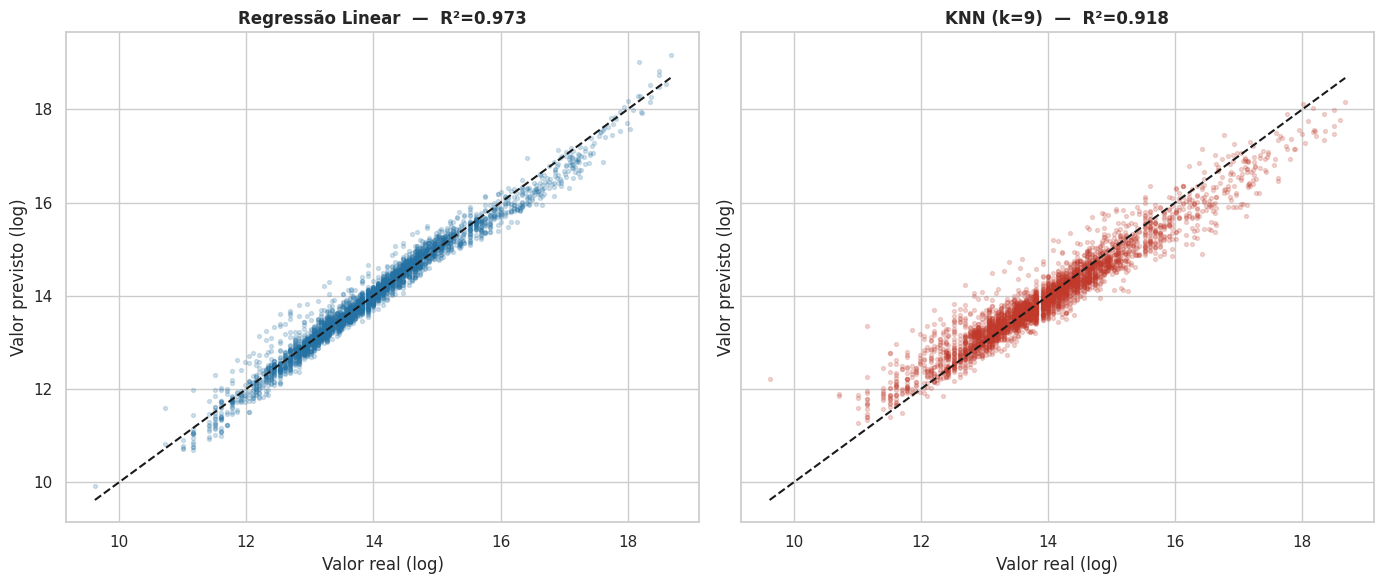

In [12]:
# Gráfico: previsto vs. real (escala log) para os dois modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, pred, nome, cor, r2 in [
    (axes[0], pred_lin, "Regressão Linear", "#2471a3", r2_lin),
    (axes[1], pred_knn, f"KNN (k={melhor_k})", "#c0392b", r2_knn)]:
    ax.scatter(y_test, pred, s=8, alpha=0.2, color=cor)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "k--", lw=1.5)
    ax.set_xlabel("Valor real (log)"); ax.set_ylabel("Valor previsto (log)")
    ax.set_title(f"{nome}  —  R²={r2:.3f}")
plt.tight_layout(); plt.show()

Os pontos se concentram em torno da diagonal (previsão perfeita) para ambos os
modelos, com dispersão maior nos extremos. O modelo com maior R² no teste é o
escolhido como principal para o dashboard. Os dois desempenham bem porque a EDA
nos guiou a transformar o alvo em log e a remover variáveis com vazamento — o que
mostra como as etapas anteriores impactam diretamente o resultado da modelagem.
Vale notar que o R² elevado (≈0,97 na Regressão Linear) é **esperado**: no FIFA, o
valor de mercado é, em boa parte, uma função das próprias notas e atributos do
jogador — não há aqui o ruído de um mercado real. Ainda assim, o exercício é válido
para **comparar os algoritmos** e para a **simulação de valor** no dashboard.

## 12. Interpretação da Regressão Linear

Como as features foram padronizadas, a magnitude dos coeficientes indica a
**importância relativa** de cada variável na previsão do valor.

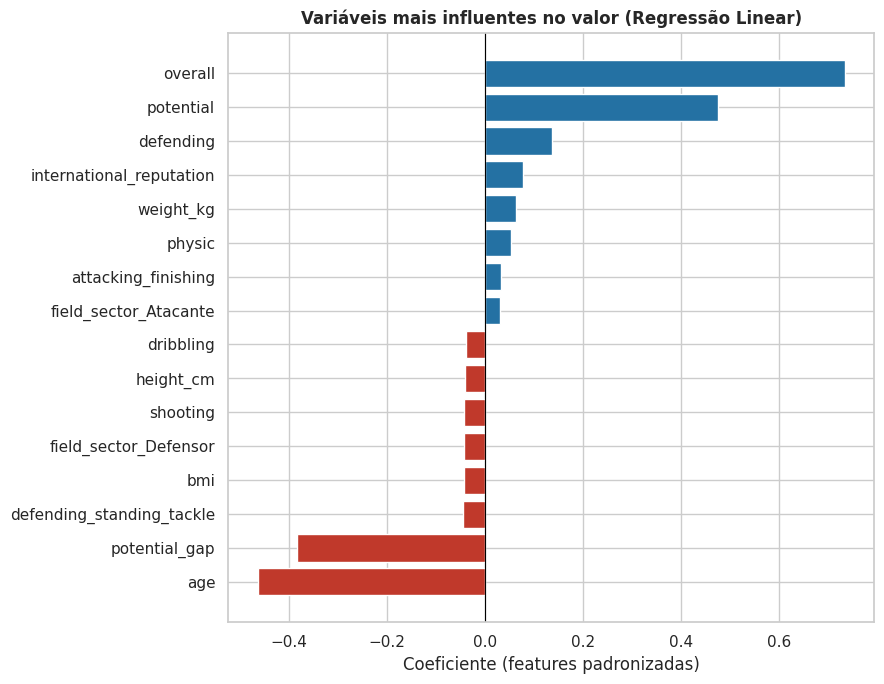

In [13]:
nomes_feat = modelo_linear.named_steps["prep"].get_feature_names_out()
coefs = modelo_linear.named_steps["reg"].coef_
imp = pd.Series(coefs, index=nomes_feat).sort_values()
top = pd.concat([imp.head(8), imp.tail(8)])

fig, ax = plt.subplots(figsize=(9, 7))
cores = ["#c0392b" if v < 0 else "#2471a3" for v in top.values]
ax.barh([n.split("__")[-1] for n in top.index], top.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coeficiente (features padronizadas)")
ax.set_title("Variáveis mais influentes no valor (Regressão Linear)")
plt.tight_layout(); plt.show()

Como esperado, `overall` e `potential` são os fatores que mais elevam o valor
previsto. Coeficientes negativos (como os ligados à idade) reduzem o valor,
coerente com o que vimos na EDA. **Ressalva importante:** devido à
multicolinearidade entre atributos, os coeficientes individuais devem ser lidos
com cautela — eles servem para uma noção geral de importância, não como efeitos
causais isolados.

## 13. Salvando os artefatos para o dashboard

Persistimos o modelo de regressão treinado, os dados com os rótulos de cluster e
um arquivo de metadados (medianas das features) que o dashboard usará para
preencher os controles do simulador.

In [14]:
os.makedirs("../models", exist_ok=True)

# 1) Melhor modelo de regressão (por R² no teste)
melhor_modelo = modelo_linear if r2_lin >= r2_knn else busca.best_estimator_
joblib.dump(melhor_modelo, "../models/modelo_regressao.joblib")

# 2) Dados com clusters e coordenadas PCA (para as abas do dashboard)
df.to_csv("../data/players_clusters.csv", index=False)

# 3) Metadados: features e medianas (valores-padrão dos sliders)
metadados = {
    "features_num": features_num,
    "features_cat": features_cat,
    "medianas": df[features_num].median().round(2).to_dict(),
    "setores": SETOR_ORDEM,
    "modelo_principal": "Regressão Linear" if r2_lin >= r2_knn else f"KNN (k={melhor_k})",
    "metricas": {"r2_linear": round(r2_lin, 3), "r2_knn": round(r2_knn, 3)},
}
with open("../models/metadados.json", "w", encoding="utf-8") as f:
    json.dump(metadados, f, ensure_ascii=False, indent=2)

print("Artefatos salvos em ../models/ e ../data/players_clusters.csv")
print("Modelo principal:", metadados["modelo_principal"])

Artefatos salvos em ../models/ e ../data/players_clusters.csv
Modelo principal: Regressão Linear


---
### Resumo da modelagem

**Parte A — K-Means (não-supervisionado):** com k=3, os clusters formados apenas a
partir dos atributos técnicos recuperaram cerca de **65% dos setores de campo**
(contra ~33% de um palpite aleatório), **dando suporte à H4**. Cada grupo tem um
perfil claro (defensivo, meio-campo, ofensivo).

**Parte B — Regressão (supervisionado):** tanto a Regressão Linear quanto o KNN
preveem bem o valor de mercado (em log). A comparação por RMSE, MAE e R² indicou o
modelo de melhor desempenho, que foi salvo para o dashboard. As decisões da EDA
(log no alvo, exclusão do salário) foram determinantes para a qualidade do
resultado.

➡️ **Próximo passo:** o **dashboard interativo** (`dashboard/app.py`), que usará os
artefatos salvos aqui para permitir a exploração dos dados, dos perfis e a
simulação de valor.